In [57]:
#getting the projections predraft
import pandas as pd
import re

def parse_text_to_df(text):
    # Global regex: match ALL player entries in a long string
    pattern = r"(\d+)\.\s+\(([^)]+)\)\s+(.+?),\s+([A-Z]{2,3})\s+\$\s*(\d+)\s+(\d+)"
    matches = re.findall(pattern, text)

    parsed_rows = []
    for match in matches:
        overall_rank, pos_rank, player, team, value, bye = match
        parsed_rows.append({
            'overall_rank': int(overall_rank),
            'pos_rank': pos_rank,
            'player': player.strip(),
            'team': team.strip(),
            'value': int(value),
            'bye': int(bye)
        })
    return pd.DataFrame(parsed_rows)

# Load full text of each file
with open("FantasyFootball23_Projections.txt", "r", errors="ignore") as file:
    ff23 = file.read()
df23 = parse_text_to_df(ff23)
df23 = df23.sort_values(by="overall_rank").reset_index(drop=True)


with open("FantasyFootball24_Projections.txt", "r", errors="ignore") as file:
    ff24 = file.read()
df24 = parse_text_to_df(ff24)
df24 = df24.sort_values(by="overall_rank").reset_index(drop=True)

with open("FantasyFootball25_Projections.txt", "r", errors="ignore") as file:
    ff25 = file.read()
df25 = parse_text_to_df(ff25)
df25 = df25.sort_values(by="overall_rank").reset_index(drop=True)

print(f"2023 players parsed: {len(df23)}")
print(f"2024 players parsed: {len(df24)}")
print(f"2025 players parsed: {len(df25)}")


2023 players parsed: 300
2024 players parsed: 300
2025 players parsed: 300


In [2]:
df23.to_csv("23proj.csv", index=False)
df24.to_csv("24proj.csv", index=False)


NameError: name 'df23' is not defined

In [59]:
import pandas as pd
import re
import unicodedata

# --- Normalize player names ---
def normalize_name(name):
    name = name.lower().replace('.', '').strip()
    name = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('utf-8')
    return name

# --- Parse draft results (shared function) ---
def extract_player_name(line):
    # Remove trailing team and position (case-insensitive)
    name = re.sub(r'\s+[A-Za-z]{2,3},?\s*[A-Za-z]{1,2}$', '', line)  # e.g., "Mia, QB"
    name = re.sub(r'\s+[A-Za-z]{2,3}$', '', name)  # e.g., "Mia"
    return name.strip()

def parse_draft_values(text):
    lines = text.strip().splitlines()
    parsed_rows = []
    i = 0
    while i < len(lines) - 2:
        pick_line = lines[i].strip()
        player_line = lines[i+1].strip()
        value_line = lines[i+2].strip()

        if re.match(r"^\d+$", pick_line) and re.match(r"^\$\d+", value_line):
            player_name = extract_player_name(player_line)
            value = int(value_line.replace('$', '').strip())
            parsed_rows.append({
                "player": player_name,
                "amount_paid": value
            })
            i += 3
        else:
            i += 1
    df = pd.DataFrame(parsed_rows)
    df["norm_player"] = df["player"].apply(normalize_name)
    return df


# --- Parse projection datasets (shared function) ---
def parse_text_to_df(text):
    # Handles lines like: 81. (WR35) George Pickens, PIT $4 6
    pattern = r"(\d+)\.\s+\(([^)]+)\)\s+([^,]+),\s+([A-Z]{2,3})\s+\$(\d+)\s+(\d+)"
    matches = re.findall(pattern, text)
    parsed_rows = []
    for match in matches:
        overall_rank, pos_rank, player, team, value, bye = match
        parsed_rows.append({
            'overall_rank': int(overall_rank),
            'pos_rank': pos_rank,
            'player': player.strip(),
            'team': team.strip(),
            'value': int(value),
            'bye': int(bye)
        })
    df = pd.DataFrame(parsed_rows)
    if not df.empty:
        df["norm_player"] = df["player"].apply(normalize_name)
    return df


# === Process 2023 Data ===
with open("FantasyFootball23_Projections.txt", "r", errors="ignore") as file:
    ff23_text = file.read()
df23 = parse_text_to_df(ff23_text)

with open("actualFF23.txt", "r", errors="ignore") as file:
    actual23_text = file.read()
df_actual23 = parse_draft_values(actual23_text)

df23_merged = df23.merge(df_actual23, on="norm_player", how="left", suffixes=("", "_actual"))
df23_merged.drop(columns=["norm_player"], inplace=True)
df23_merged = df23_merged.sort_values(by="overall_rank").reset_index(drop=True)
df23_merged["rankSPC"] = df23_merged["pos_rank"].str.extract(r"(\d+)$").astype(int)
df23_merged["position"] = df23_merged["pos_rank"].astype(str).str.extract(r"([a-zA-Z]+)")[0].str.upper()



df23_merged.to_csv("23proj_with_actuals.csv", index=False)

# === Process 2024 Data ===
with open("FantasyFootball24_Projections.txt", "r", errors="ignore") as file:
    ff24_text = file.read()
df24 = parse_text_to_df(ff24_text)

with open("actualFF24.txt", "r", errors="ignore") as file:
    actual24_text = file.read()
df_actual24 = parse_draft_values(actual24_text)

df24_merged = df24.merge(df_actual24, on="norm_player", how="left", suffixes=("", "_actual"))
df24_merged.drop(columns=["norm_player"], inplace=True)
df24_merged = df24_merged.sort_values(by="overall_rank").reset_index(drop=True)
df24_merged["rankSPC"] = df24_merged["pos_rank"].str.extract(r"(\d+)$").astype(int)
df24_merged["position"] = df24_merged["pos_rank"].astype(str).str.extract(r"([a-zA-Z]+)")[0].str.upper()


df24_merged.to_csv("24proj_with_actuals.csv", index=False)

# --- Done ---
print(f"2023 projection file: {len(df23_merged)} rows")
print(f"2024 projection file: {len(df24_merged)} rows")
print(f"Matched 2023 draft picks: {df_actual23['player'].nunique()}")
print(f"Matched 2024 draft picks: {df_actual24['player'].nunique()}")


2023 projection file: 300 rows
2024 projection file: 300 rows
Matched 2023 draft picks: 180
Matched 2024 draft picks: 180


In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
import pandas as pd

def run_sklearn_regression(df, label):
    # Drop rows with any NaN values
    df_clean = df.dropna(subset=['value', 'overall_rank', 'rankSPC', 'position', 'amount_paid'])

    # Define features and target
    X = df_clean[['value', 'overall_rank', 'rankSPC', 'position']]
    y = df_clean['amount_paid']

    # One-hot encode categorical column
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(drop='first'), ['position'])
        ],
        remainder='passthrough'
    )

    # Create and fit pipeline
    pipeline = make_pipeline(preprocessor, LinearRegression())
    pipeline.fit(X, y)

    # Get feature names and coefficients
    feature_names = pipeline.named_steps['columntransformer'].get_feature_names_out()
    coefficients = pipeline.named_steps['linearregression'].coef_

    # Combine into a DataFrame
    coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    print(f"\nRegression results for {label}:")
    print(coef_df)

# Run regression on both dataframes
run_sklearn_regression(df23_merged, "df23_merged")
run_sklearn_regression(df24_merged, "df24_merged")



Regression results for df23_merged:
                   Feature  Coefficient
0         cat__position_RB    -0.445456
1         cat__position_TE    -0.113274
2         cat__position_WR     0.948584
3         remainder__value     1.180294
4  remainder__overall_rank     0.011687
5       remainder__rankSPC    -0.025330

Regression results for df24_merged:
                   Feature  Coefficient
0         cat__position_RB     1.636289
1         cat__position_TE     0.017730
2         cat__position_WR     2.625120
3         remainder__value     1.095376
4  remainder__overall_rank     0.013133
5       remainder__rankSPC    -0.055169


In [61]:


def run_regression(df, label):
    # Drop missing values
    df_clean = df.dropna(subset=['value', 'overall_rank', 'rankSPC', 'position', 'amount_paid'])

    # Features and target
    X = df_clean[['value', 'overall_rank', 'rankSPC', 'position']]
    y = df_clean['amount_paid']

    # Preprocessing pipeline
    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(drop='first'), ['position'])],
        remainder='passthrough'
    )

    # Build and fit pipeline
    pipeline = make_pipeline(preprocessor, LinearRegression())
    pipeline.fit(X, y)

    # Get feature names and coefficients
    feature_names = pipeline.named_steps['columntransformer'].get_feature_names_out()
    coefficients = pipeline.named_steps['linearregression'].coef_

    # Print results
    coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
    print(f"\nRegression results for {label}:")
    print(coef_df)

# Combine both dataframes
combined_df = pd.concat([df23_merged, df24_merged], ignore_index=True)

# Run regression on combined data
run_regression(combined_df, "Combined 2023 + 2024")

# Run regression only on players with value > 8
high_value_df = combined_df[combined_df['value'] > 8]
run_regression(high_value_df, "Players with Value > 8")



Regression results for Combined 2023 + 2024:
                   Feature  Coefficient
0         cat__position_RB     0.369985
1         cat__position_TE    -0.041810
2         cat__position_WR     1.479487
3         remainder__value     1.140268
4  remainder__overall_rank     0.010418
5       remainder__rankSPC    -0.033549

Regression results for Players with Value > 8:
                   Feature  Coefficient
0         cat__position_RB    -3.943834
1         cat__position_TE    -2.512893
2         cat__position_WR    -1.820489
3         remainder__value     1.472922
4  remainder__overall_rank     0.205042
5       remainder__rankSPC     0.032157


Major Insight: Among top-tier players:

Position mattered less or was reversed — teams may have paid up for QBs or overvalued them.

The model likely shows a premium for elite QBs, causing RB/WR/TE to show up with negative coefficients (relative to QB).

Could also indicate positional scarcity perceptions — people may bid aggressively for a few top QBs (e.g., Mahomes, Allen) even if their projections are similar to top RBs/WRs.

In [ ]:

        remainder='passthrough'
    )

    # Build and fit pipeline
    pipeline = make_pipeline(preprocessor, LinearRegression())
    pipeline.fit(X, y)

    # Get coefficients
    feature_names = pipeline.named_steps['columntransformer'].get_feature_names_out()
    coefficients = pipeline.named_steps['linearregression'].coef_

    # Combine into DataFrame
    coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    print(f"\nRegression results for {label} (no QBs):")
    print(coef_df)

# Combine data
combined_df = pd.concat([df23_merged, df24_merged], ignore_index=True)

# Run regressions
run_regression(combined_df, "Combined 2023 + 2024 (WR, RB, TE only)")

# High-value players only
high_value_df = combined_df[combined_df['value'] > 8]
run_regression(high_value_df, "Value > 8 (WR, RB, TE only)")



Regression results for Combined 2023 + 2024 (WR, RB, TE only) (no QBs):
                   Feature  Coefficient
0         cat__position_TE    -1.279981
1         cat__position_WR     1.368535
2         remainder__value     1.125805
3  remainder__overall_rank     0.018340
4       remainder__rankSPC    -0.064624

Regression results for Value > 8 (WR, RB, TE only) (no QBs):
                   Feature  Coefficient
0         cat__position_TE    -1.701562
1         cat__position_WR     2.508528
2         remainder__value     1.685877
3  remainder__overall_rank     0.482770
4       remainder__rankSPC    -0.138754


Feature	Coefficient	Interpretation
position_TE	–1.70	TEs worth even less than RBs among top players
position_WR	+2.51	WRs worth much more than RBs in elite tier
value	+1.69	Huge influence: a 1-point "value" bump → ~$1.69 more paid
overall_rank	+0.48	Larger effect, though may reflect correlation with "value"
rankSPC	–0.14	Stronger negative impact — teams paid less for worse positional rank

In [84]:


def run_regression(df, label):
    # Drop missing values
    df_clean = df.dropna(subset=['value', 'overall_rank', 'rankSPC', 'position', 'amount_paid'])

    # Filter to WR, RB, TE only
    df_filtered = df_clean[df_clean['position'].isin(['RB', 'WR', 'TE'])]

    # Further filter to value > 20
    df_top = df_filtered[df_filtered['value'] >= 20]

    # Features and target
    X = df_top[['value', 'overall_rank', 'rankSPC', 'position']]
    y = df_top['amount_paid']

    # Preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(drop='first'), ['position'])  # Drop first to avoid multicollinearity
        ],
        remainder='passthrough'
    )

    # Pipeline
    pipeline = make_pipeline(preprocessor, LinearRegression())
    pipeline.fit(X, y)

    # Get results
    feature_names = pipeline.named_steps['columntransformer'].get_feature_names_out()
    coefficients = pipeline.named_steps['linearregression'].coef_

    coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
    print(f"\nRegression results for {label} (value > 20, no QBs):")
    print(coef_df)

# Run on combined df23_merged + df24_merged
combined_df = pd.concat([df23_merged, df24_merged], ignore_index=True)
run_regression(combined_df, "Top Tier Players")



Regression results for Top Tier Players (value > 20, no QBs):
                   Feature  Coefficient
0         cat__position_TE    -6.418100
1         cat__position_WR     4.034033
2         remainder__value     1.504203
3  remainder__overall_rank     0.558369
4       remainder__rankSPC    -0.830488


In [64]:
df25["rankSPC"] = df25["pos_rank"].str.extract(r"(\d+)$").astype(int)
df25["position"] = df25["pos_rank"].astype(str).str.extract(r"([a-zA-Z]+)")[0].str.upper()

df25.to_csv("25proj.csv", index=False)

In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
import pandas as pd

# Define the regression function
def run_regression(df, label):
    # Drop missing values
    df_clean = df.dropna(subset=['value', 'overall_rank', 'rankSPC', 'position', 'amount_paid'])

    # Filter to WR, RB, TE only
    df_filtered = df_clean[df_clean['position'].isin(['RB', 'WR', 'TE'])]

    # Further filter to value > 20
    df_top = df_filtered[(df_filtered['value'] >=25)]

    # Features and target
    X = df_top[['value', 'overall_rank', 'rankSPC', 'position']]
    y = df_top['amount_paid']

    # Preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(drop='first'), ['position'])  # Drop first to avoid multicollinearity
        ],
        remainder='passthrough'
    )

    # Pipeline
    pipeline = make_pipeline(preprocessor, LinearRegression())
    pipeline.fit(X, y)

    # Get results
    feature_names = pipeline.named_steps['columntransformer'].get_feature_names_out()
    coefficients = pipeline.named_steps['linearregression'].coef_

    coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
    print(f"\nRegression results for {label} (value > 20, no QBs):")
    print(coef_df)

    return pipeline

# Combine training data
combined_df = pd.concat([df23_merged, df24_merged], ignore_index=True)

# Train the model
pipeline = run_regression(combined_df, "Top Tier Players")

# Prepare df25 and predict
df25_clean = df25.dropna(subset=['value', 'overall_rank', 'rankSPC', 'position'])
df25_filtered = df25_clean[df25_clean['position'].isin(['RB', 'WR', 'TE'])]
df25_top = df25_filtered[(df25_filtered['value'] >=25)]
X_new = df25_top[['value', 'overall_rank', 'rankSPC', 'position']]
df25_top['predicted_amount_paid'] = pipeline.predict(X_new)

# Include the "player" variable in the output
output = df25_top[['player', 'value', 'overall_rank', 'rankSPC', 'position', 'predicted_amount_paid']]
output["predicted_amount_paid"] = output["predicted_amount_paid"].round(3)

# View predictions
#print(output)



Regression results for Top Tier Players (value > 20, no QBs):
                   Feature  Coefficient
0         cat__position_TE    -2.390926
1         cat__position_WR     3.775080
2         remainder__value     0.836776
3  remainder__overall_rank    -0.045742
4       remainder__rankSPC    -1.227358


C:\Users\scwvi\AppData\Local\Temp\ipykernel_6752\3625729845.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df25_top['predicted_amount_paid'] = pipeline.predict(X_new)
C:\Users\scwvi\AppData\Local\Temp\ipykernel_6752\3625729845.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  output["predicted_amount_paid"] = output["predicted_amount_paid"].round(3)


In [88]:
output.to_csv("predicted_amount_paid25.csv", index=False)

In [82]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
import pandas as pd

# Define the regression function
def run_regression(df, label):
    # Drop missing values
    df_clean = df.dropna(subset=['value', 'overall_rank', 'rankSPC', 'position', 'amount_paid'])

    # Filter to QBs only
    df_filtered = df_clean[df_clean['position'] == 'QB']

    # Further filter for specific value range (e.g., <7 as in original logic)
    df_top = df_filtered

    # Features and target
    X = df_top[['value', 'overall_rank', 'rankSPC', 'position']]
    y = df_top['amount_paid']

    # Preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(drop='first'), ['position'])  # Drop first to avoid multicollinearity
        ],
        remainder='passthrough'
    )

    # Pipeline
    pipeline = make_pipeline(preprocessor, LinearRegression())
    pipeline.fit(X, y)

    # Get results
    feature_names = pipeline.named_steps['columntransformer'].get_feature_names_out()
    coefficients = pipeline.named_steps['linearregression'].coef_

    coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
    print(f"\nRegression results for {label} (QBs only, value > 0):")
    print(coef_df)

    return pipeline

# Combine training data
combined_df = pd.concat([df23_merged, df24_merged], ignore_index=True)

# Train the model
pipeline = run_regression(combined_df, "Top Tier QBs")

# Prepare df25 and predict
df25_clean = df25.dropna(subset=['value', 'overall_rank', 'rankSPC', 'position'])
df25_filtered = df25_clean[df25_clean['position'] == 'QB']
df25_top = df25_filtered
X_new = df25_top[['value', 'overall_rank', 'rankSPC', 'position']]
df25_top['predicted_amount_paid'] = pipeline.predict(X_new)

# Include the "player" variable in the output
output = df25_top[['player', 'value', 'overall_rank', 'rankSPC', 'position', 'predicted_amount_paid']]
output["predicted_amount_paid"] = output["predicted_amount_paid"].round(3)

# Export the output DataFrame to a CSV file without the index column

output = output.sort_values(by='overall_rank')
output.to_csv("predicted_qbs.csv", index=False)

# Confirm the output file is saved
#print("CSV file saved as 'predicted_qbs.csv'.")



Regression results for Top Tier QBs (QBs only, value > 0):
                   Feature  Coefficient
0         remainder__value     1.370949
1  remainder__overall_rank     0.101642
2       remainder__rankSPC    -0.605158


C:\Users\scwvi\AppData\Local\Temp\ipykernel_6752\3436261593.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df25_top['predicted_amount_paid'] = pipeline.predict(X_new)
C:\Users\scwvi\AppData\Local\Temp\ipykernel_6752\3436261593.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  output["predicted_amount_paid"] = output["predicted_amount_paid"].round(3)


In [68]:
import pandas as pd
from pulp import LpProblem, LpVariable, lpSum, LpMaximize, LpBinary, LpStatus

# Load data
df = pd.read_csv("Totaljuly.csv").dropna(subset=['player', 'position', 'projPts', 'predicted_amount_paid'])

# Ensure player names are unique
df = df.drop_duplicates(subset='player')
df["predicted_amount_paid"] = df['predicted_amount_paid']

# LP Problem
prob = LpProblem("Fantasy_Team_Selection", LpMaximize)
player_vars = {
    row['player']: LpVariable(row['player'], cat=LpBinary)
    for _, row in df.iterrows()
}

# Objective: maximize projPts
prob += lpSum(player_vars[row['player']] * row['projPts'] for _, row in df.iterrows())

# Constraints:
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'QB'].iterrows()) == 1
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'].isin(['RB', 'WR', 'TE'])].iterrows()) == 7
prob += lpSum(player_vars[row['player']] for _, row in df.iterrows()) == 8
prob += lpSum(player_vars[row['player']] * row['predicted_amount_paid'] for _, row in df.iterrows()) <= 193
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'RB'].iterrows()) >= 2
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'WR'].iterrows()) >= 2
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'TE'].iterrows()) >= 1

# Solve
prob.solve()

if LpStatus[prob.status] == 'Optimal':
    selected_names = [p for p, var in player_vars.items() if var.varValue == 1]
    selected_players = df[df['player'].isin(selected_names)]
    total_projPts = selected_players['projPts'].sum()
    total_cost = selected_players['predicted_amount_paid'].sum()

    print("\n🏆 Best Team Found:")
    print(selected_players[['player', 'position', 'projPts', 'predicted_amount_paid']])
    print(f"\nTotal Projected Points: {total_projPts:.2f}")
    print(f"Total Cost: {total_cost:.2f}")
else:
    print("❌ No valid team found.")



🏆 Best Team Found:
              player position  projPts  predicted_amount_paid
0      Ja'Marr Chase       WR     21.0                 71.917
22    Kyren Williams       RB     17.9                 33.256
30         Joe Mixon       RB     17.3                 22.767
35       Rashee Rice       WR     15.5                 20.656
39   Omarion Hampton       RB     16.1                 15.465
42      Alvin Kamara       RB     15.8                 13.396
55       Sam LaPorta       TE     12.1                 10.086
235      Brock Purdy       QB     18.2                  4.824

Total Projected Points: 133.90
Total Cost: 192.37


In [105]:
import pandas as pd
from pulp import LpProblem, LpVariable, lpSum, LpMaximize, LpBinary, LpStatus

# Load data
df = pd.read_csv("TotalUpdated6.7.csv").dropna(subset=['player', 'position', 'projPts', 'predicted_amount_paid'])
df = df.drop_duplicates(subset='player')

# === DYNAMIC INPUTS === #
budget_remaining = 193  # Adjust as needed
slots_total = 8         # Total number of roster spots left

# Position-specific needs
need_qb = 1
need_rb = 2
need_wr = 2
need_te =  1
need_flex = 2           # Flex can be RB/WR/TE

# === OPTIMIZATION === #
prob = LpProblem("Live_Draft_Team_Optimizer", LpMaximize)

# Decision variables
player_vars = {
    row['player']: LpVariable(row['player'], cat=LpBinary)
    for _, row in df.iterrows()
}

# Objective: Maximize projected points
prob += lpSum(player_vars[row['player']] * row['projPts'] for _, row in df.iterrows())

# Constraint: Total cost within budget
prob += lpSum(player_vars[row['player']] * row['predicted_amount_paid'] for _, row in df.iterrows()) <= budget_remaining

# Constraint: Total number of players
prob += lpSum(player_vars[row['player']] for _, row in df.iterrows()) == slots_total

# Position-specific constraints
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'QB'].iterrows()) >= need_qb
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'RB'].iterrows()) >= need_rb
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'WR'].iterrows()) >= need_wr
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'TE'].iterrows()) >= need_te

# FLEX spots (RB, WR, TE combined)
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'].isin(['RB', 'WR', 'TE'])].iterrows()) >= (need_rb + need_wr + need_te + need_flex)

# Solve
prob.solve()

# Output
if LpStatus[prob.status] == 'Optimal':
    selected_names = [p for p, var in player_vars.items() if var.varValue == 1]
    selected_players = df[df['player'].isin(selected_names)]
    total_projPts = selected_players['projPts'].sum()
    total_cost = selected_players['predicted_amount_paid'].sum()

    print("\n🏈 Recommended Picks:")
    print(selected_players[['player', 'position', 'projPts', 'predicted_amount_paid']])
    print(f"\nTotal Projected Points: {total_projPts:.2f}")
    print(f"Total Cost: {total_cost:.2f}")
else:
    print("❌ No valid team found with current constraints.")



🏈 Recommended Picks:
              player position  projPts  predicted_amount_paid
0      Ja'Marr Chase       WR     20.7                 71.917
22    Kyren Williams       RB     16.4                 33.256
30         Joe Mixon       RB     16.1                 22.767
33     George Kittle       TE     13.3                 23.950
42      Alvin Kamara       RB     15.5                 13.396
44     Chuba Hubbard       RB     15.2                 13.249
73      Chris Godwin       WR     14.8                  6.169
232  Patrick Mahomes       QB     19.1                  7.736

Total Projected Points: 131.10
Total Cost: 192.44


In [73]:
df = pd.read_csv("Totaljuly.csv",index_col=False)
df["PPD"] = (df["projPts"] / df['predicted_amount_paid']).round(2)

df.to_csv("Totaljuly.csv",index=False)


In [124]:
import pandas as pd
from pulp import LpProblem, LpVariable, lpSum, LpMaximize, LpBinary, LpStatus

# Load data
df = pd.read_csv("espnAPIData.csv").dropna(subset=['player', 'position', 'WAR', 'predicted_amount_paid'])
df = df.drop_duplicates(subset='player')

df['WAR'] = pd.to_numeric(df['WAR'], errors='coerce')  # Convert to numeric, setting invalid values to NaN
df['predicted_amount_paid'] = pd.to_numeric(df['predicted_amount_paid'], errors='coerce')  # Same here

# Replace null values in 'predicted_amount_paid' with -10
df['predicted_amount_paid'] = df['predicted_amount_paid'].fillna(-10)

# Drop rows where 'WAR' has null values since it's critical for optimization
df = df.dropna(subset=['WAR'])
# === DYNAMIC INPUTS === #
budget_remaining = 193  # Adjust as needed
slots_total = 8         # Total number of roster spots left

# Position-specific needs
need_qb = 1
need_rb = 2
need_wr = 2
need_te = 1
need_flex = 2           # Flex can be RB/WR/TE

# === OPTIMIZATION === #
prob = LpProblem("Live_Draft_Team_Optimizer", LpMaximize)

# Decision variables
player_vars = {
    row['player']: LpVariable(row['player'], cat=LpBinary)
    for _, row in df.iterrows()
}

# Objective: Maximize WAR
prob += lpSum(player_vars[row['player']] * row['WAR'] for _, row in df.iterrows())

# Constraint: Total cost within budget
prob += lpSum(player_vars[row['player']] * row['predicted_amount_paid'] for _, row in df.iterrows()) <= budget_remaining

# Constraint: Total number of players
prob += lpSum(player_vars[row['player']] for _, row in df.iterrows()) == slots_total

# Position-specific constraints
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'QB'].iterrows()) >= need_qb
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'RB'].iterrows()) >= need_rb
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'WR'].iterrows()) >= need_wr
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'TE'].iterrows()) >= need_te

# FLEX spots (RB, WR, TE combined)
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'].isin(['RB', 'WR', 'TE'])].iterrows()) >= (need_rb + need_wr + need_te + need_flex)

# Solve
prob.solve()

# Output
if LpStatus[prob.status] == 'Optimal':
    selected_names = [p for p, var in player_vars.items() if var.varValue == 1]
    selected_players = df[df['player'].isin(selected_names)]
    total_war = selected_players['WAR'].sum()
    total_cost = selected_players['predicted_amount_paid'].sum()
    total_projPts = selected_players['projPtsAvg'].sum()

    print("\n🏈 Recommended Picks:")
    print(selected_players[['player', 'position', 'WAR', 'predicted_amount_paid']])
    print(f"\nTotal WAR: {total_war:.2f}")
    print(f"Total Cost: {total_cost:.2f}")
    print(f"Total Ppg: {total_projPts:.2f}")
else:
    print("❌ No valid team found with current constraints.")



🏈 Recommended Picks:
             player position    WAR  predicted_amount_paid
0     Ja'Marr Chase       WR  4.119                 71.917
17    George Kittle       TE  1.755                 23.950
32        Joe Mixon       RB  2.833                 22.767
43     Alvin Kamara       RB  2.613                 13.396
47  Patrick Mahomes       QB  1.048                  7.736
49    Chuba Hubbard       RB  2.493                 13.249
52     James Conner       RB  2.548                 14.343
57      Rashee Rice       WR  1.829                 20.656

Total WAR: 19.24
Total Cost: 188.01
Total Ppg: 130.07


In [ ]:
#MY PREDICTIONS
df = pd.read_csv("espnAPIData.csv").dropna(subset=['player', 'position', 'projPtsAvg', 'predicted_amount_paid'])
df = df.drop_duplicates(subset='player')

# Convert columns to numeric, handle errors by coercing invalids to NaN
df['projPtsAvg'] = pd.to_numeric(df['projPtsAvg'], errors='coerce')
df['predicted_amount_paid'] = pd.to_numeric(df['predicted_amount_paid'], errors='coerce')

# Replace null predicted_amount_paid with -10
df['predicted_amount_paid'] = df['predicted_amount_paid'].fillna(-10)

# Drop rows where projPtsAvg is null (critical for optimization)
df = df.dropna(subset=['projPtsAvg'])

# === DYNAMIC INPUTS === #
budget_remaining = 193  # Adjust as needed
slots_total = 8         # Total number of roster spots left

# Position-specific needs
need_qb = 1
need_rb = 2
need_wr = 2
need_te = 1
need_flex = 2           # Flex can be RB/WR/TE

# === OPTIMIZATION === #
prob = LpProblem("Live_Draft_Team_Optimizer", LpMaximize)

# Decision variables
player_vars = {
    row['player']: LpVariable(row['player'], cat=LpBinary)
    for _, row in df.iterrows()
}

# Objective: Maximize projected points per game
prob += lpSum(player_vars[row['player']] * row['projPtsAvg'] for _, row in df.iterrows())

# Constraint: Total cost within budget
prob += lpSum(player_vars[row['player']] * row['predicted_amount_paid'] for _, row in df.iterrows()) <= budget_remaining

# Constraint: Total number of players
prob += lpSum(player_vars[row['player']] for _, row in df.iterrows()) == slots_total

# Position-specific constraints
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'QB'].iterrows()) >= need_qb
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'RB'].iterrows()) >= need_rb
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'WR'].iterrows()) >= need_wr
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'TE'].iterrows()) >= need_te

# FLEX spots (RB, WR, TE combined)
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'].isin(['RB', 'WR', 'TE'])].iterrows()) >= (need_rb + need_wr + need_te + need_flex)

# Solve
prob.solve()

# Output
if LpStatus[prob.status] == 'Optimal':
    selected_names = [p for p, var in player_vars.items() if var.varValue == 1]
    selected_players = df[df['player'].isin(selected_names)]
    total_projPts = selected_players['projPtsAvg'].sum()
    total_cost = selected_players['predicted_amount_paid'].sum()

    print("\n🏈 Recommended Picks:")
    print(selected_players[['player', 'position', 'projPtsAvg', 'predicted_amount_paid']])
    print(f"\nTotal Projected PPG: {total_projPts:.2f}")
    print(f"Total Cost: {total_cost:.2f}")
else:
    print("❌ No valid team found with current constraints.")



🏈 Recommended Picks:
             player position  projPtsAvg  predicted_amount_paid
0     Ja'Marr Chase       WR       20.74                 71.917
17    George Kittle       TE       13.33                 23.950
30   Kyren Williams       RB       16.42                 33.256
32        Joe Mixon       RB       16.09                 22.767
43     Alvin Kamara       RB       15.52                 13.396
47  Patrick Mahomes       QB       19.06                  7.736
49    Chuba Hubbard       RB       15.20                 13.249
73     Chris Godwin       WR       14.65                  6.169

Total Projected PPG: 131.01
Total Cost: 192.44


In [153]:
#ESPN PREDICTIONS
df = pd.read_csv("espnAPIData.csv").dropna(subset=['player', 'position', 'projPtsAvg', 'espnPaid'])
df = df.drop_duplicates(subset='player')

# Convert columns to numeric, handle errors by coercing invalids to NaN
df['projPtsAvg'] = pd.to_numeric(df['projPtsAvg'], errors='coerce')
df['espnPaid'] = pd.to_numeric(df['espnPaid'], errors='coerce')

# Replace null predicted_amount_paid with -10
df['espnPaid'] = df['espnPaid'].fillna(-10)

# Drop rows where projPtsAvg is null (critical for optimization)
df = df.dropna(subset=['projPtsAvg'])
# df["espnPaid"] = df["espnPaid"]+4
# === DYNAMIC INPUTS === #
budget_remaining = 193  # Adjust as needed
slots_total = 8         # Total number of roster spots left

# Position-specific needs
need_qb = 1
need_rb = 2
need_wr = 2
need_te = 1
need_flex = 2           # Flex can be RB/WR/TE

# === OPTIMIZATION === #
prob = LpProblem("Live_Draft_Team_Optimizer", LpMaximize)

# Decision variables
player_vars = {
    row['player']: LpVariable(row['player'], cat=LpBinary)
    for _, row in df.iterrows()
}

# Objective: Maximize projected points per game
prob += lpSum(player_vars[row['player']] * row['projPtsAvg'] for _, row in df.iterrows())

# Constraint: Total cost within budget
prob += lpSum(player_vars[row['player']] * row['espnPaid'] for _, row in df.iterrows()) <= budget_remaining

# Constraint: Total number of players
prob += lpSum(player_vars[row['player']] for _, row in df.iterrows()) == slots_total

# Position-specific constraints
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'QB'].iterrows()) >= need_qb
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'RB'].iterrows()) >= need_rb
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'WR'].iterrows()) >= need_wr
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'TE'].iterrows()) >= need_te

# FLEX spots (RB, WR, TE combined)
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'].isin(['RB', 'WR', 'TE'])].iterrows()) >= (need_rb + need_wr + need_te + need_flex)

# Solve
prob.solve()

# Output
if LpStatus[prob.status] == 'Optimal':
    selected_names = [p for p, var in player_vars.items() if var.varValue == 1]
    selected_players = df[df['player'].isin(selected_names)]
    total_projPts = selected_players['projPtsAvg'].sum()
    total_cost = selected_players['espnPaid'].sum()

    print("\n🏈 Recommended Picks:")
    print(selected_players[['player', 'position', 'projPtsAvg', 'espnPaid']])
    print(f"\nTotal Projected PPG: {total_projPts:.2f}")
    print(f"Total Cost: {total_cost:.2f}")
else:
    print("❌ No valid team found with current constraints.")



🏈 Recommended Picks:
                player position  projPtsAvg  espnPaid
0        Ja'Marr Chase       WR       20.75      71.0
33       George Kittle       TE       13.32      26.0
35  Kenneth Walker III       RB       15.55      27.0
37           Joe Mixon       RB       15.04      16.0
51        James Conner       RB       15.37      19.0
56        Alvin Kamara       RB       15.51      26.0
80        Chris Godwin       WR       14.65       6.0
91         Brock Purdy       QB       18.04       2.0

Total Projected PPG: 128.23
Total Cost: 193.00


In [186]:
#ESPN PREDICTIONS
df = pd.read_csv("dataWithCR_updated.csv").dropna(subset=['player', 'position', 'projPtsAvg', 'espnPaid'])
df = df.drop_duplicates(subset='player')

# Convert columns to numeric, handle errors by coercing invalids to NaN
df['POR'] = pd.to_numeric(df['POR'], errors='coerce')
df['espnPaid'] = pd.to_numeric(df['espnPaid'], errors='coerce')

# Replace null predicted_amount_paid with -10
df['espnPaid'] = df['espnPaid'].fillna(-10)
df['POR+WAR'] = df["POR"]+df["WAR"]

# Drop rows where projPtsAvg is null (critical for optimization)
df = df.dropna(subset=['POR'])
# df["espnPaid"] = df["espnPaid"]+4
# === DYNAMIC INPUTS === #
budget_remaining = 193  # Adjust as needed
slots_total = 8         # Total number of roster spots left

# Position-specific needs
need_qb = 1
need_rb = 2
need_wr = 2
need_te = 1
need_flex = 2           # Flex can be RB/WR/TE

# === OPTIMIZATION === #
prob = LpProblem("Live_Draft_Team_Optimizer", LpMaximize)

# Decision variables
player_vars = {
    row['player']: LpVariable(row['player'], cat=LpBinary)
    for _, row in df.iterrows()
}

# Objective: Maximize projected points per game
prob += lpSum(player_vars[row['player']] * row['projPtsAvg'] for _, row in df.iterrows())

# Constraint: Total cost within budget
prob += lpSum(player_vars[row['player']] * row['espnPaid'] for _, row in df.iterrows()) <= budget_remaining

# Constraint: Total number of players
prob += lpSum(player_vars[row['player']] for _, row in df.iterrows()) == slots_total

# Position-specific constraints
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'QB'].iterrows()) >= need_qb
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'RB'].iterrows()) >= need_rb
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'WR'].iterrows()) >= need_wr
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'TE'].iterrows()) >= need_te

# FLEX spots (RB, WR, TE combined)
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'].isin(['RB', 'WR', 'TE'])].iterrows()) >= (need_rb + need_wr + need_te + need_flex)

# Solve
prob.solve()

# Output
if LpStatus[prob.status] == 'Optimal':
    selected_names = [p for p, var in player_vars.items() if var.varValue == 1]
    selected_players = df[df['player'].isin(selected_names)]
    total_projPts = selected_players['projPtsAvg'].sum()
    total_POR = selected_players['POR'].sum()
    total_cost = selected_players['espnPaid'].sum()
    total_WAR = selected_players['WAR'].sum()
    totalWARPOR = selected_players["POR+WAR"].sum()

    print("\n🏈 Recommended Picks:")
    print(selected_players[['player', 'position', 'projPtsAvg', 'espnPaid',"POR"]])
    print(f"\nTotal Projected PPG: {total_projPts:.2f}")
    print(f"Total Cost: {total_cost:.2f}")
    print(f"Total POR: {total_POR:.2f}")
    print(f"Total WAR: {total_WAR:.2f}")
    print(f"Total WAR+POR: {totalWARPOR:.2f}")
else:
    print("❌ No valid team found with current constraints.")



🏈 Recommended Picks:
                player position  projPtsAvg  espnPaid    POR
0        Ja'Marr Chase       WR       20.75      71.0  10.10
33       George Kittle       TE       13.32      26.0   4.61
35  Kenneth Walker III       RB       15.55      27.0   6.41
37           Joe Mixon       RB       15.04      16.0   5.90
51        James Conner       RB       15.37      19.0   6.23
56        Alvin Kamara       RB       15.51      26.0   6.37
80        Chris Godwin       WR       14.65       6.0   4.00
91         Brock Purdy       QB       18.04       2.0   1.68

Total Projected PPG: 128.23
Total Cost: 193.00
Total POR: 45.30
Total WAR: 4.63
Total WAR+POR: 49.93


In [26]:
from pulp import LpProblem, LpVariable, lpSum, LpMaximize, LpBinary, LpStatus
import pandas as pd

# === Load and Clean Data === #
df = pd.read_csv("dataWithCR_updated.csv").dropna(subset=['player', 'position', 'projPtsAvg','projPtsTotal', 'espnPaid',"WAR","draftedValue"])
df = df.drop_duplicates(subset='player')
df2 = pd.read_csv("FantasyPros_Fantasy_Football_Points_PPR.csv").dropna(subset=["Player","Pos","AVG","TTL"])
df2 = df2[df2["AVG"]>5]
# Convert columns to numeric, handle errors by coercing invalids to NaN
df['projPtsAvg'] = pd.to_numeric(df['projPtsAvg'], errors='coerce')
df['espnPaid'] = pd.to_numeric(df['draftedValue'], errors='coerce')
df['CR'] = pd.to_numeric(df['CR'], errors='coerce')
df['start%'] = pd.to_numeric(df['start%'], errors='coerce')  # Ensure start% is numeric

# Replace null predicted_amount_paid with -10
df['espnPaid'] = df['espnPaid'].fillna(-10)

# Drop rows where necessary data is null (critical for optimization)
dfmerged = df.merge(df2, left_on="player", right_on="Player", how="inner")
dfmerged = dfmerged.dropna(subset=['AVG', 'CR', 'start%','TTL','projPtsTotal','projPtsAvg'])
#dfmerged = dfmerged[df['list'] == 'y']
# === DYNAMIC INPUTS === #
df = dfmerged
budget_remaining = 190# Adjust as needed
slots_total = 8         # Total number of roster spots left

# Position-specific needs
need_qb = 1
need_rb = 2
need_wr = 2
need_te = 1
need_flex = 2           # Flex can be RB/WR/TE

# === OPTIMIZATION === #
print("Solving optimization with weighted factors...")
prob = LpProblem("Live_Draft_Team_Optimizer", LpMaximize)

# Decision variables
player_vars = {
    row['player']: LpVariable(row['player'], cat=LpBinary)
    for _, row in df.iterrows()
}

# Objective: Weighted factors (90% PPG, 5% start%, 5% (1 - CR))
prob += lpSum(
    player_vars[row['player']] * (
        0*row['WAR'] +
        0*row['AVG'] +
        1*row['projPtsTotal']+
        0*(1 - row['CR'])  # Inverting CR as lower is better
    )
    for _, row in df.iterrows()
)

# Constraint: Total cost within budget
prob += lpSum(player_vars[row['player']] * row['espnPaid'] for _, row in df.iterrows()) <= budget_remaining

# Constraint: Total number of players
prob += lpSum(player_vars[row['player']] for _, row in df.iterrows()) == slots_total

# Position-specific constraints
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'QB'].iterrows()) <= need_qb
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'RB'].iterrows()) >= need_rb
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'WR'].iterrows()) >= need_wr
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'] == 'TE'].iterrows()) >= need_te
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'].isin(['RB', 'WR','TE'])].iterrows()) >= (need_rb + need_wr + need_flex)
# prob += player_vars['Drake London'] == 1
# # prob += player_vars['Bijan Robinson'] == 1
# prob += player_vars['Chase Brown'] == 1
# #prob += player_vars['Trey McBride'] == 1
# prob += player_vars['Chris Godwin'] == 0
# prob += player_vars['Alvin Kamara'] == 0
# prob += player_vars['Brock Purdy'] == 1
# prob += player_vars['George Kittle'] == 1
# prob += player_vars['Ladd McConkey'] == 1
# prob += player_vars['Tee Higgins'] == 0
# prob += player_vars['Breece Hall'] == 0
# prob += player_vars['Chuba Hubbard'] == 0
# prob += player_vars['Davante Adams'] == 0
# prob += player_vars['Josh Jacobs'] == 0
# Solve
prob.solve()

# === OUTPUT RESULTS === #
if LpStatus[prob.status] == 'Optimal':
    selected_names = [p for p, var in player_vars.items() if var.varValue == 1]
    selected_players = df[df['player'].isin(selected_names)]
    print("Optimization successful!")
    print("Recommended Players:")
    total_avgPts = selected_players['AVG'].sum()
    #selected_players['TTL14']= round(selected_players['TTL']*(13/17),2)
    #total_Pts = selected_players['TTL14'].sum()
    total_proj = selected_players['projPtsAvg'].sum()
    
    print(selected_players[['player', 'position', 'AVG', 'espnPaid',"projPtsAvg",'projPtsTotal',]])
    print(f"\nTotal Actual PPG: {total_avgPts:.2f}")
    print(f"\nTotal Actual Points: {total_avgPts*13:.2f}")
    print(f"\nTotal Projected Points: {total_proj*13:.2f}")
    #print(f"Total Cost: {total_cost:.2f}")
    # print(f"Total POR: {total_POR:.2f}")
    #print(f"Total WAR: {total_WAR:.2f}")
    #print(f"Total WAR+POR: {totalWARPOR:.2f}")
    
else:
    print("❌ Optimization failed: No valid team found.")


Solving optimization with weighted factors...
Optimization successful!
Recommended Players:
              player position   AVG  espnPaid  projPtsAvg  projPtsTotal
16      Trey McBride       TE  18.9      32.0       15.25        259.28
17   Jonathan Taylor       RB  22.3      40.0       17.46        296.80
20     Derrick Henry       RB  16.7      34.0       16.51        280.75
23    Jayden Daniels       QB  16.8      20.0       21.61        367.33
31    Terry McLaurin       WR  11.6      19.0       14.52        246.80
49      James Conner       RB   8.3      23.0       15.38        261.39
54      Alvin Kamara       RB   9.2      13.0       15.58        264.79
61  Courtland Sutton       WR  13.6       9.0       13.42        228.12

Total Actual PPG: 117.40

Total Actual Points: 1526.20

Total Projected Points: 1686.49


In [ ]:
# ================================
# 1600+ POINT TEAM ENUMERATOR
# ================================

from pulp import LpProblem, LpVariable, lpSum, LpMaximize, LpBinary, LpStatus
import pandas as pd
from collections import Counter

# === Load Data (same as your pipeline) ===
df = pd.read_csv("dataWithCR_updated.csv").dropna(subset=['player', 'position', 'projPtsAvg','projPtsTotal', 'espnPaid',"WAR","draftedValue"])
df = df.drop_duplicates(subset='player')

df2 = pd.read_csv("FantasyPros_Fantasy_Football_Points_PPR.csv").dropna(subset=["Player","Pos","AVG","TTL"])
df2 = df2[df2["AVG"]>5]

df['projPtsAvg'] = pd.to_numeric(df['projPtsAvg'], errors='coerce')
df['espnPaid'] = pd.to_numeric(df['draftedValue'], errors='coerce')
df['CR'] = pd.to_numeric(df['CR'], errors='coerce')
df['start%'] = pd.to_numeric(df['start%'], errors='coerce')
df['espnPaid'] = df['espnPaid'].fillna(-10)

dfmerged = df.merge(df2, left_on="player", right_on="Player", how="inner")
dfmerged = dfmerged.dropna(subset=['AVG', 'CR', 'start%','TTL','projPtsTotal','projPtsAvg'])
df = dfmerged

# === League Settings ===
budget_remaining = 190
slots_total = 8
need_qb = 1
need_rb = 2
need_wr = 2
need_te = 1
need_flex = 2

WEEKS = 13
TARGET_SEASON_PTS = 1600
TARGET_PPG = TARGET_SEASON_PTS / WEEKS

# === Build LP ===
prob = LpProblem("1600_Point_Roster_Finder", LpMaximize)

player_vars = {row['player']: LpVariable(row['player'], cat=LpBinary)
               for _, row in df.iterrows()}

# Objective: maximize projected points
prob += lpSum(player_vars[row['player']] * row['projPtsAvg']
              for _, row in df.iterrows())

# === Constraints ===
prob += lpSum(player_vars[row['player']] * row['espnPaid']
              for _, row in df.iterrows()) <= budget_remaining

prob += lpSum(player_vars[row['player']] for _, row in df.iterrows()) == slots_total

prob += lpSum(player_vars[row['player']] for _, row in df[df['position']=="QB"].iterrows()) <= need_qb
prob += lpSum(player_vars[row['player']] for _, row in df[df['position']=="RB"].iterrows()) >= need_rb
prob += lpSum(player_vars[row['player']] for _, row in df[df['position']=="WR"].iterrows()) >= need_wr
prob += lpSum(player_vars[row['player']] for _, row in df[df['position']=="TE"].iterrows()) >= need_te
prob += lpSum(player_vars[row['player']] for _, row in df[df['position'].isin(["RB","WR","TE"])].iterrows()) >= (need_rb + need_wr + need_flex)

# === 1600-point constraint ===
prob += lpSum(player_vars[row['player']] * row['projPtsAvg']
              for _, row in df.iterrows()) >= TARGET_PPG

# === Enumerate all 1600+ teams ===
MAX_TEAMS = 100
solutions = []

for k in range(MAX_TEAMS):
    prob.solve()
    if LpStatus[prob.status] != "Optimal":
        print(f"Stopped after {k} championship teams.")
        break

    selected = [p for p, v in player_vars.items() if v.value() == 1]
    solutions.append(selected)

    # block this roster
    prob += lpSum(player_vars[p] for p in selected) <= slots_total - 1

# === Score each roster ===
teams = []
for roster in solutions:
    team_df = df[df['player'].isin(roster)]
    ppg = team_df['projPtsAvg'].sum()
    cost = team_df['espnPaid'].sum()

    teams.append({
        "players": ", ".join(roster),
        "ppg": round(ppg,2),
        "season_pts": round(ppg * WEEKS,1),
        "cost": round(cost,2)
    })

teams_df = pd.DataFrame(teams).sort_values("season_pts", ascending=False)

print("\n=== TOP 10 1600+ TEAMS ===")
print(teams_df.head(10))

# === Championship Leverage ===
counter = Counter()
for team in solutions:
    for p in team:
        counter[p] += 1

leverage = pd.DataFrame([
    {"player": p, "appearances": c, "share": c / len(solutions)}
    for p,c in counter.items()
]).sort_values("share", ascending=False)

print("\n=== CHAMPIONSHIP LEVERAGE ===")
print(leverage.head(20))



=== TOP 10 1600+ TEAMS ===
                                             players     ppg  season_pts  \
0  Ja'Marr Chase, Trey McBride, Jayden Daniels, R...  131.36      1707.7   
1  Ja'Marr Chase, Trey McBride, Jayden Daniels, R...  131.16      1705.1   
2  Trey McBride, Jonathan Taylor, Derrick Henry, ...  131.11      1704.4   
3  Trey McBride, Jonathan Taylor, Derrick Henry, ...  131.05      1703.6   
4  Trey McBride, Jonathan Taylor, Derrick Henry, ...  131.04      1703.5   
5  Trey McBride, Jonathan Taylor, Jayden Daniels,...  131.02      1703.3   
6  Ja'Marr Chase, Trey McBride, Jayden Daniels, R...  130.99      1702.9   
7  Brock Bowers, Jonathan Taylor, Derrick Henry, ...  130.97      1702.6   
8  Trey McBride, Jonathan Taylor, Derrick Henry, ...  130.91      1701.8   
9  Ja'Marr Chase, Trey McBride, Jayden Daniels, R...  130.88      1701.4   

    cost  
0  190.0  
1  190.0  
2  188.0  
3  187.0  
4  190.0  
5  186.0  
6  187.0  
7  190.0  
8  190.0  
9  189.0  

=== CHAMPIONS

In [ ]:
leverage.to_csv("leverage.csv")
teams_df.to_csv("teamsDF.csv")



0.287121248270268 5.710846018036929


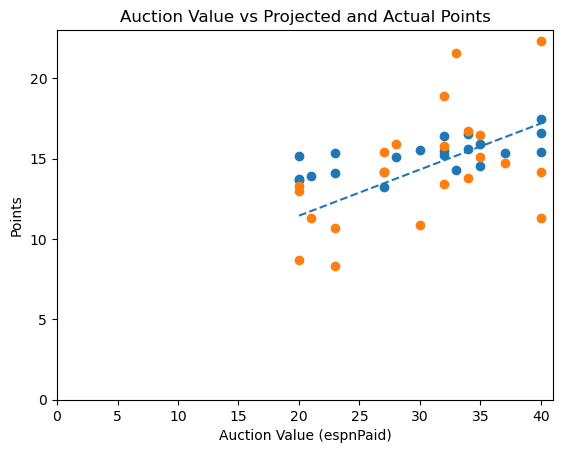

In [52]:
import matplotlib.pyplot as plt
dfmerged = dfmerged[dfmerged["position"]!="QB"]
dfmerged = dfmerged[dfmerged["espnPaid"]>=20]
dfmerged = dfmerged[dfmerged["espnPaid"]<=40]
# Scatter plot: auction value vs projected points
plt.scatter(dfmerged["espnPaid"], dfmerged["projPtsAvg"], label="Projected Points")

# Scatter plot: auction value vs actual total points (TTL)
plt.scatter(dfmerged["espnPaid"], dfmerged["AVG"], label="Actual Total Points (TTL)")

plt.xlabel("Auction Value (espnPaid)")
plt.ylabel("Points")
plt.title("Auction Value vs Projected and Actual Points")
# for _, row in dfmerged.iterrows():
#     color = "red" if row["AVG"] > row["projPtsAvg"] else "blue"
#     plt.plot(
#         [row["espnPaid"], row["espnPaid"]],
#         [row["projPtsAvg"], row["AVG"]],
#         color=color,
#         alpha=0.5
#     )
import numpy as np

# Line of best fit for projected points
m, b = np.polyfit(dfmerged["espnPaid"], dfmerged["AVG"], 1)
x_vals = np.linspace(dfmerged["espnPaid"].min(), dfmerged["espnPaid"].max(), 100)
y_vals = m * x_vals + b
plt.ylim(0)
plt.xlim(0)
plt.plot(x_vals, y_vals, linestyle="--", label="Best Fit (Projected Points)")
print(m,b)
plt.show()